# Animal Pipeline — Demo

This notebook walks through the full pipeline end to end:
1. Generate NER dataset
2. Download image dataset
3. Train NER model
4. Train image classifier
5. Run the full pipeline on examples

> **Prerequisites**: `pip install -r requirements.txt` and `PYTHONPATH=.` set from the project root.

In [1]:
import os
from pathlib import Path

# move from notebooks/ to project root so all paths resolve correctly
os.chdir('..')

assert Path('src').exists(), (...)
print('Working directory:', Path.cwd())

Working directory: M:\PyCharm Projects\winstarsai\task2


---
## Step 1 — Generate NER Dataset

Creates synthetic BIO-tagged sentences from templates × animal variants.
Produces `data/processed/` and `data/splits/`.

In [2]:
# run the generation script
%run scripts/generate_ner_dataset.py

Generating NER dataset
Total samples generated: 3764
B-ANIMAL tokens: 3752
O tokens: 18955
O / B ratio: 5.1x
Saved full dataset  → M:\PyCharm Projects\winstarsai\task2\data\processed\ner_dataset.json
Saved train split   → M:\PyCharm Projects\winstarsai\task2\data\splits\train.json  (3011 samples)
Saved val   split   → M:\PyCharm Projects\winstarsai\task2\data\splits\val.json  (376 samples)
Saved test  split   → M:\PyCharm Projects\winstarsai\task2\data\splits\test.json  (377 samples)
Saved normalization table to M:\PyCharm Projects\winstarsai\task2\data\processed\normalization.json (67 entries)

Sample records
  sentence : That animal looks like a thoroughbred.
  tokens   : ['That', 'animal', 'looks', 'like', 'a', 'thoroughbred.']
  labels   : ['O', 'O', 'O', 'O', 'O', 'B-ANIMAL']
  canonical: horse

  sentence : A tarantula is visible here.
  tokens   : ['A', 'tarantula', 'is', 'visible', 'here.']
  labels   : ['O', 'B-ANIMAL', 'O', 'O', 'O']
  canonical: spider

  sentence : A poodle

In [3]:
# inspect a few generated samples
import json, random
random.seed(0)

with open('data/splits/train.json') as f:
    train_records = json.load(f)

print(f'Train samples: {len(train_records)}')
print()
for r in random.sample(train_records, 5):
    print(f'sentence : {r["sentence"]}')
    print(f'tokens : {r["tokens"]}')
    print(f'labels : {r["labels"]}')
    print(f'canonical: {r["canonical"]}')
    print()

Train samples: 3011

sentence : I'm almost certain this is a caterpillar.
tokens : ["I'm", 'almost', 'certain', 'this', 'is', 'a', 'caterpillar.']
labels : ['O', 'O', 'O', 'O', 'O', 'O', 'B-ANIMAL']
canonical: butterfly

sentence : Look at this equine!
tokens : ['Look', 'at', 'this', 'equine!']
labels : ['O', 'O', 'O', 'B-ANIMAL']
canonical: horse

sentence : It looks like there's a pachyderm here.
tokens : ['It', 'looks', 'like', "there's", 'a', 'pachyderm', 'here.']
labels : ['O', 'O', 'O', 'O', 'O', 'B-ANIMAL', 'O']
canonical: elephant

sentence : The cattle in this photo is interesting.
tokens : ['The', 'cattle', 'in', 'this', 'photo', 'is', 'interesting.']
labels : ['O', 'B-ANIMAL', 'O', 'O', 'O', 'O', 'O']
canonical: cow

sentence : Do you think that is a chicken?
tokens : ['Do', 'you', 'think', 'that', 'is', 'a', 'chicken?']
labels : ['O', 'O', 'O', 'O', 'O', 'O', 'B-ANIMAL']
canonical: chicken



In [4]:
# inspect normalization table
with open('data/processed/normalization.json') as f:
    norm_table = json.load(f)

print(f'Total variants: {len(norm_table)}')
print()
# show a few entries per canonical class
from collections import defaultdict
by_class = defaultdict(list)
for variant, canonical in norm_table.items():
    by_class[canonical].append(variant)

for cls, variants in sorted(by_class.items()):
    print(f'{cls} {variants}')

Total variants: 67

butterfly ['butterfly', 'butterflies', 'moth', 'caterpillar']
cat ['cat', 'cats', 'kitten', 'kittens', 'feline', 'tabby', 'siamese', 'persian', 'kitty']
chicken ['chicken', 'chickens', 'hen', 'rooster', 'chick', 'poultry']
cow ['cow', 'cows', 'cattle', 'bull', 'calf', 'bovine', 'ox']
dog ['dog', 'dogs', 'puppy', 'puppies', 'canine', 'hound', 'german shepherd', 'golden retriever', 'labrador', 'poodle', 'bulldog', 'husky', 'beagle', 'chihuahua']
elephant ['elephant', 'elephants', 'tusker', 'pachyderm']
horse ['horse', 'horses', 'mare', 'stallion', 'foal', 'pony', 'equine', 'mustang', 'thoroughbred']
sheep ['sheep', 'lamb', 'lambs', 'ewe', 'ram', 'flock']
spider ['spider', 'spiders', 'arachnid', 'tarantula', 'black widow']
squirrel ['squirrel', 'squirrels', 'chipmunk']


---
## Step 2 — Download Image Dataset

Downloads Rapidata/Animals-10 from HuggingFace and splits into train/val/test.
~23k images, cached locally after first download.

In [5]:
%run scripts/download_dataset.py

Loading Rapidata/Animals-10 from HuggingFace...


Loaded 23554 images
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['Butterfly', 'Cat', 'Chicken', 'Cow', 'Dog', 'Elephant', 'Horse', 'Sheep', 'Spider', 'Squirrel'])}

Label mapping (label):
0: butterfly
1: cat
2: chicken
3: cow
4: dog
5: elephant
6: horse
7: sheep
8: spider
9: squirrel

Grouping by class...
  butterfly   : 1603 images
  cat         : 1199 images
  chicken     : 2993 images
  cow         : 1797 images
  dog         : 4811 images
  elephant    : 1037 images
  horse       : 2598 images
  sheep       : 1376 images
  spider      : 4340 images
  squirrel    : 1800 images

Splitting and saving images...
train: 1282val: 160test: 161
train: 959val: 119test: 121
train: 2394val: 299test: 300
train: 1437val: 179test: 181
train: 3848val: 481test: 482
train: 829val: 103test: 105
train: 2078val: 259test: 261
train: 1100val: 137test: 139
train: 3472val: 434test: 434
train: 1440val: 180test: 180

Total images saved: 23554
Output directory: M:\PyCharm Proj

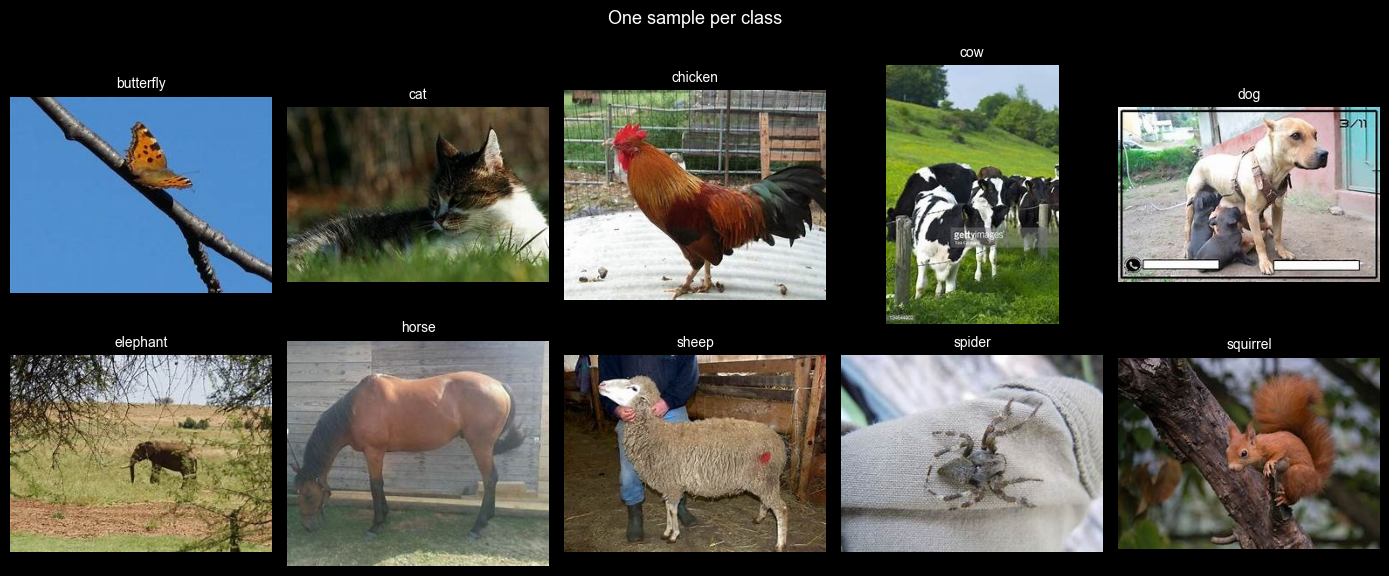

In [6]:
# verify structure
import matplotlib.pyplot as plt
from PIL import Image as PILImage

DATA_DIR = Path('data/raw/animals10')
CLASSES  = sorted([d.name for d in (DATA_DIR / 'train').iterdir() if d.is_dir()])

# show one sample per class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, cls in zip(axes.flat, CLASSES):
    img_path = next((DATA_DIR / 'train' / cls).iterdir())
    ax.imshow(PILImage.open(img_path).convert('RGB'))
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.suptitle('One sample per class', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 3 — Train NER Model

Fine-tunes DistilBERT for animal entity extraction.
Saves checkpoint to `models/ner/`.

In [7]:
from src.ner.train import train, parse_args
import sys

# simulate CLI args — equivalent to:
# python -m src.ner.train --epochs 5 --lr 3e-5
sys.argv = ['train', '--epochs', '5', '--lr', '3e-5']
ner_trainer = train(parse_args())

Loading tokenizer and model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading datasets...
train: 3011 samples
val: 376 samples
Tokenizing and aligning labels...


Map:   0%|          | 0/3011 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Saving best model to M:\PyCharm Projects\winstarsai\task2\models\ner...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
# test NER on a few sentences before moving on
from src.ner.model import load_trained_model, predict, extract_animal_entities
from src.pipeline.normalization import AnimalNormalizer

ner_model, tokenizer = load_trained_model(Path('models/ner'))
normalizer  = AnimalNormalizer()

test_sentences = [
    'There is a cow in the picture.',
    'I think that is a golden retriever.',
    'Could this be a tarantula?',
    'This is a beautiful photo.',            # negative
    'My neighbor has a persian cat.',
]

print(f'{"Sentence":<45} {"Entities":<20} {"Canonical"}')
print('-' * 80)
for sentence in test_sentences:
    preds = predict(sentence, ner_model, tokenizer)
    entities = extract_animal_entities(preds)
    canonical = [normalizer.normalize(e) for e in entities]
    print(f'{sentence:<45} {str(entities):<20} {canonical}')

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Sentence                                      Entities             Canonical
--------------------------------------------------------------------------------
There is a cow in the picture.                ['cow']              ['cow']
I think that is a golden retriever.           ['golden retriever'] ['dog']
Could this be a tarantula?                    ['tarantula']        ['spider']
This is a beautiful photo.                    []                   []
My neighbor has a persian cat.                ['persian cat']      ['cat']


---
## Step 4 — Train Image Classifier

Fine-tunes EfficientNet-B0 in two phases on the Animals-10 dataset.
Saves best weights to `models/classifier/best_model.pth`.

In [9]:
from src.classifier.train import train as clf_train, parse_args as clf_parse_args

# simulate CLI args
sys.argv = ['train',
            '--phase1_epochs', '5',
            '--phase2_epochs', '5',
            '--batch_size', '128']
clf_model = clf_train(clf_parse_args())

Device: cuda

Loading datasets...
train: 18839 images
val:  2351 images
test:  2364 images

Phase 1 (head only) (lr=0.001)
Epoch: 1 | Train loss: 0.7156 | Train acc: 0.8465 | Val loss: 0.3055 | Val acc: 0.9417
Epoch: 2 | Train loss: 0.3027 | Train acc: 0.9232 | Val loss: 0.2242 | Val acc: 0.9456
Epoch: 3 | Train loss: 0.2569 | Train acc: 0.9281 | Val loss: 0.1971 | Val acc: 0.9494
Epoch: 4 | Train loss: 0.2309 | Train acc: 0.9344 | Val loss: 0.1950 | Val acc: 0.9519
Epoch: 5 | Train loss: 0.2272 | Train acc: 0.9358 | Val loss: 0.1883 | Val acc: 0.9524

Best val accuracy (phase 1): 0.9524

Unfreezing last backbone block...
Trainable params: 424,970 / 4,020,358 (10.6%)

Phase 2 (fine-tuning) (lr=0.0001)
Epoch: 1 | Train loss: 0.2079 | Train acc: 0.9395 | Val loss: 0.1659 | Val acc: 0.9545
Epoch: 2 | Train loss: 0.1821 | Train acc: 0.9436 | Val loss: 0.1516 | Val acc: 0.9553
Epoch: 3 | Train loss: 0.1733 | Train acc: 0.9458 | Val loss: 0.1427 | Val acc: 0.9575
Epoch: 4 | Train loss: 0.162

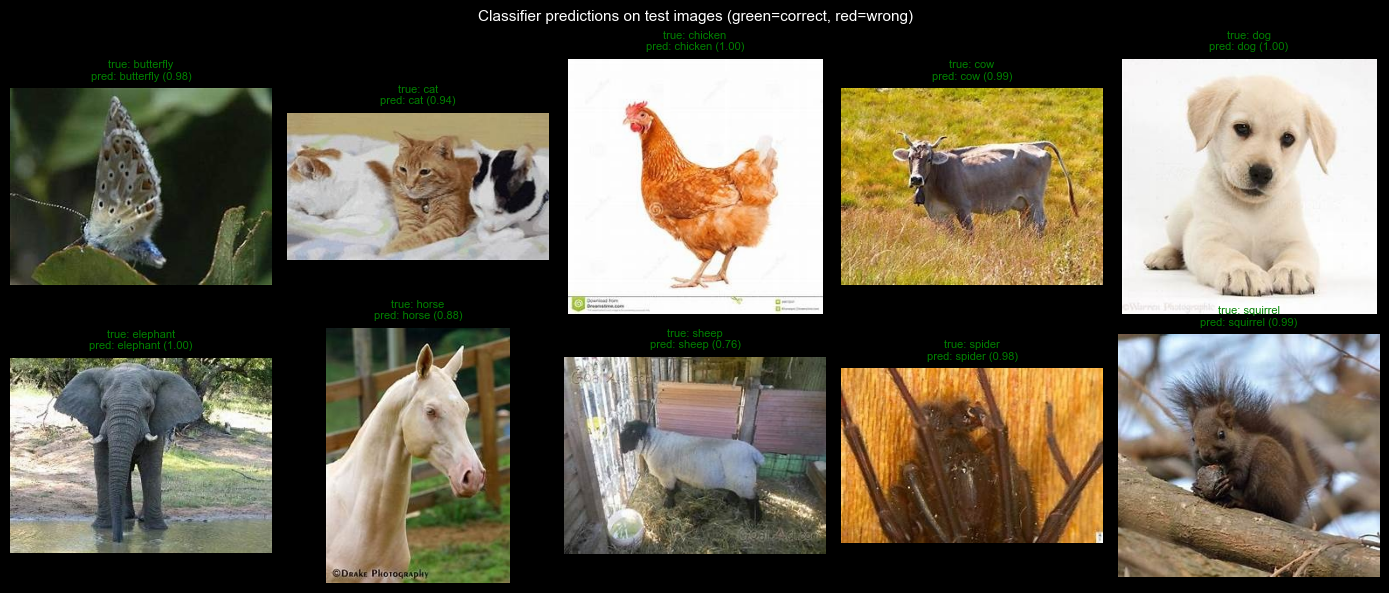

In [10]:
# test classifier on a sample image from each class
from src.classifier.model import load_trained_model as load_clf, predict as clf_predict
import random

clf = load_clf(Path('models/classifier/best_model.pth'))

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, cls in zip(axes.flat, CLASSES):
    folder = DATA_DIR / 'test' / cls
    img_path = random.choice(list(folder.iterdir()))
    img = PILImage.open(img_path).convert('RGB')
    preds = clf_predict(img, clf)
    top = preds[0]
    correct = top['class'] == cls
    color = 'green' if correct else 'red'
    ax.imshow(img)
    ax.set_title(f'true: {cls}\npred: {top["class"]} ({top["confidence"]:.2f})',
                 fontsize=8, color=color)
    ax.axis('off')
plt.suptitle('Classifier predictions on test images (green=correct, red=wrong)', fontsize=11)
plt.tight_layout()
plt.show()

---
## Step 5 — Run the Full Pipeline

Wire NER + classifier together and test on image + text pairs.

In [11]:
from src.pipeline.pipeline import AnimalPipeline

pipeline = AnimalPipeline()

Loading NER model from M:\PyCharm Projects\winstarsai\task2\models\ner...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loading classifier from M:\PyCharm Projects\winstarsai\task2\models\classifier\best_model.pth...
Pipeline ready.


In [12]:
# build test cases: (text, image_path, expected_result)
test_cases = []

# correct claims — should return True
for cls in CLASSES:
    img_path = random.choice(list((DATA_DIR / 'test' / cls).iterdir()))
    test_cases.append((f'There is a {cls} in the picture.', img_path, True))

# wrong claims — pick mismatched class, should return False
for cls in CLASSES[:3]:
    wrong_cls = random.choice([c for c in CLASSES if c != cls])
    img_path  = random.choice(list((DATA_DIR / 'test' / cls).iterdir()))
    test_cases.append((f'There is a {wrong_cls} in the picture.', img_path, False))

# run pipeline
results = []
for text, img_path, expected in test_cases:
    img    = PILImage.open(img_path).convert('RGB')
    result = pipeline.run(text, img)
    results.append((text, img_path, expected, result))

# print summary
correct = sum(1 for _, _, exp, res in results if res.match == exp)
print(f'Pipeline accuracy: {correct}/{len(results)} ({correct/len(results)*100:.0f}%)\n')
print(f'{"Text":<45} {"Expected":<10} {"Got":<10} {"Conf":>8}  Pass')
print('-' * 85)
for text, _, expected, result in results:
    status = '✅' if result.match == expected else '❌'
    print(f'{text[:43]:<45} {str(expected):<10} {str(result.match):<10} '
          f'{result.image_confidence:>8.4f}  {status}')
    if result.reason:
        print(f'  → {result.reason}')

Pipeline accuracy: 13/13 (100%)

Text                                          Expected   Got            Conf  Pass
-------------------------------------------------------------------------------------
There is a butterfly in the picture.          True       True         0.9998  ✅
There is a cat in the picture.                True       True         0.9398  ✅
There is a chicken in the picture.            True       True         0.9964  ✅
There is a cow in the picture.                True       True         0.9081  ✅
There is a dog in the picture.                True       True         0.9726  ✅
There is a elephant in the picture.           True       True         0.9364  ✅
There is a horse in the picture.              True       True         0.9959  ✅
There is a sheep in the picture.              True       True         0.9783  ✅
There is a spider in the picture.             True       True         0.9998  ✅
There is a squirrel in the picture.           True       True         0.5124  

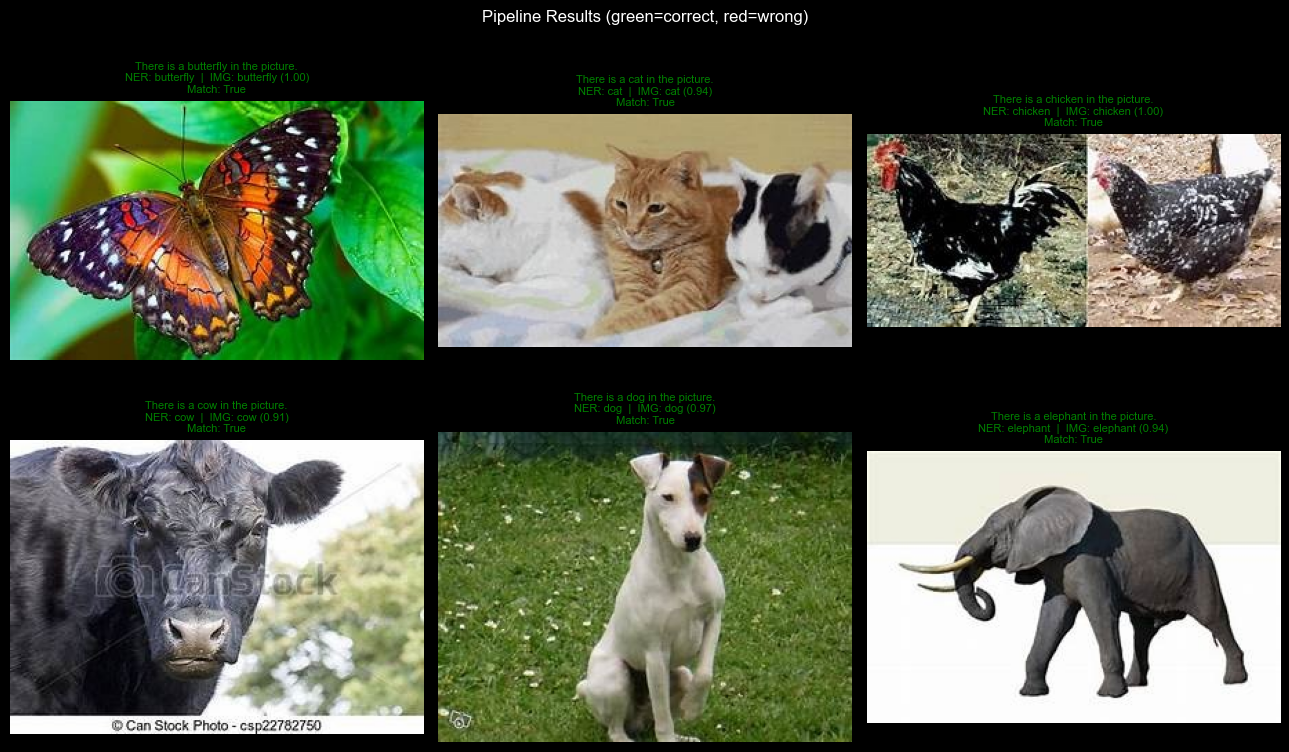

In [13]:
# visualize a few pipeline results
n_show = 6
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for ax, (text, img_path, expected, result) in zip(axes.flat, results[:n_show]):
    img   = PILImage.open(img_path).convert('RGB')
    color = 'green' if result.match == expected else 'red'
    ax.imshow(img)
    ax.set_title(
        f'{text[:40]}\n'
        f'NER: {result.normalized_entity}  |  '
        f'IMG: {result.image_top_class} ({result.image_confidence:.2f})\n'
        f'Match: {result.match}',
        fontsize=8, color=color
    )
    ax.axis('off')

plt.suptitle('Pipeline Results (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
# test with varied phrasings — the real test of NER generalization
varied_texts = [
    ('I think that is a golden retriever.',          'dog'),
    ('Could this be a tabby?',                       'cat'),
    ('Looks like a calf to me.',                     'cow'),
    ('What a beautiful butterfly!',                  'butterfly'),
    ('My friend thinks there is a hen here.',        'chicken'),
    ('That animal looks like a stallion.',           'horse'),
]

print('Testing varied phrasings with matching images:\n')
print(f'{"Text":<45} {"NER→":<8} {"Canonical":<12} {"Match"}')
print('-' * 70)

for text, expected_cls in varied_texts:
    img_path = random.choice(list((DATA_DIR / 'test' / expected_cls).iterdir()))
    img      = PILImage.open(img_path).convert('RGB')
    result   = pipeline.run(text, img)
    status   = '✅' if result.match else '❌'
    print(f'{text[:43]:<45} {str(result.extracted_entities):<8} '
          f'{str(result.normalized_entity):<12} {status}')

Testing varied phrasings with matching images:

Text                                          NER→     Canonical    Match
----------------------------------------------------------------------
I think that is a golden retriever.           ['golden retriever'] dog          ✅
Could this be a tabby?                        ['tabby'] cat          ✅
Looks like a calf to me.                      ['calf'] cow          ✅
What a beautiful butterfly!                   ['butterfly'] butterfly    ✅
My friend thinks there is a hen here.         ['hen']  chicken      ✅
That animal looks like a stallion.            ['stallion'] horse        ✅
